# Predictive Coding Neural Network from Scratch

Dieses Notebook ist bewusst als **Lern- und Implementationsgeruest** formuliert. Es soll dich Schritt fuer Schritt dazu bringen, ein kleines Predictive Coding Neural Network (PCN/PCNN) selbst aufzubauen, statt dir eine fertige Loesung hinzustellen.

**Ziel:** Du implementierst eine hierarchische generative Architektur, in der hoehere latente Schichten die darunterliegende Schicht vorhersagen. Lernen entsteht durch zwei Phasen: schnelle Inferenz der latenten Zustaende und langsamere Gewichtsupdates.

## Arbeitsweise

Die Aufgaben sind so angelegt, dass du zuerst ein kleines NumPy-Modell baust. Damit siehst du jede Matrixmultiplikation und jedes Fehler-Signal direkt.

- Implementiere die `TODO`-Stellen in kleinen Schritten.
- Fuehre nach jeder Aufgabe die Check-Zellen aus.
- Starte mit kleinen Dimensionen und wenigen Inferenzschritten.
- Erst wenn die Energie stabil sinkt, lohnt sich ein Klassifikations-Experiment.

Die Theorie orientiert sich vor allem an `ressources/2506.06332v1.pdf`. Das zweite Paper `ressources/5667_Towards_Stable_Learning_i.pdf` ist besonders fuer Stabilitaetsfragen relevant.

In [19]:
# Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from tqdm import tqdm

RNG = np.random.default_rng(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Theoriekompass: Was ist ein PCN?

Ein Predictive Coding Network besteht aus einem sichtbaren Input-Layer $x^{(0)}$ und latenten Layern $x^{(1)}, \dots, x^{(L)}$. Jede hoehere Schicht versucht, die darunterliegende Schicht vorherzusagen:

$$a^{(l)} = W^{(l)}x^{(l+1)}$$

$$\hat{x}^{(l)} = f^{(l)}(a^{(l)})$$

$$\epsilon^{(l)} = x^{(l)} - \hat{x}^{(l)}$$

Die Energie des Netzes ist die Summe der quadratischen Vorhersagefehler:

$$\mathcal{L} = \frac{1}{2}\sum_{l=0}^{L-1}\|\epsilon^{(l)}\|^2$$

**Wichtiges mentales Bild:** Vorhersagen laufen top-down, Fehler laufen bottom-up. Bei fixen Gewichten werden zuerst die latenten Zustaende angepasst. Danach werden die Gewichte anhand der finalen Fehler angepasst.

### Aufgabe 1: Notation in Code uebersetzen

Lege zuerst die Dimensionen fuer ein kleines PCN fest. Verwende als Startpunkt eine zweidimensionale Eingabe, zwei latente Schichten und kleine Hidden-Dimensionen.

**Deine Aufgabe:**
- Entscheide, welche Rolle jede Dimension in `dims` spielt.
- Implementiere eine Aktivierungsfunktion und ihre Ableitung.
- Pruefe per Hand, welche Shapes die Matrizen $W^{(l)}$ haben muessen.

In [3]:
# dims = [d_0, d_1, ..., d_L]
# d_0 ist die Input-Dimension. d_L ist die oberste latente Dimension.
dims = [2, 8, 4]

def activation(a):
    """Elementweise Nichtlinearitaet f(a)."""
    # leaky ReLU: f(a) = a, falls a > 0, sonst f(a) = 0.01 * a
    # Vecorized implementation:
    a = np.array(a)
    return np.where(a > 0, a, 0.01 * a)


def activation_derivative(a):
    """Ableitung f'(a), passend zu activation."""
    return np.where(a > 0, 1, 0.01)


for l in range(len(dims) - 1):
    print(f"W[{l}] should map x^({l+1}) -> x^({l}): shape ({dims[l]}, {dims[l+1]})")

W[0] should map x^(1) -> x^(0): shape (2, 8)
W[1] should map x^(2) -> x^(1): shape (8, 4)


## 2. Generative Schichten

Jede Schicht speichert ein Gewicht $W^{(l)}$, das von $x^{(l+1)}$ nach $x^{(l)}$ vorhersagt. In dieser NumPy-Version verwenden wir zunaechst keine Bias-Terme, damit die PCN-Gleichungen klar bleiben.

**Deine Aufgabe:** Implementiere die drei Grundbausteine:
- `init_weights`: initialisiert alle $W^{(l)}$.
- `predict_layer`: berechnet $a^{(l)}$ und $\hat{x}^{(l)}$.
- `compute_errors`: berechnet alle Fehler $\epsilon^{(l)}$ und gain-modulierten Fehler $h^{(l)} = f'(a^{(l)}) \odot \epsilon^{(l)}$.

In [4]:
def init_weights(dims, rng=RNG, scale=0.5):
    """Return list [W0, W1, ...], where W[l].shape == (dims[l], dims[l+1])."""
    weights = []
    for l in range(len(dims) - 1):
        # Xavier/Glorot 
        sigma = np.sqrt(2 / (dims[l] + dims[l+1]))
        W_l = sigma * rng.standard_normal((dims[l], dims[l+1]))
        weights.append(W_l)
    return weights

def predict_layer(W_l, x_above):
    """Compute a_l and x_hat_l for one layer.

    x_above shape: (batch_size, d_{l+1})
    W_l shape:     (d_l, d_{l+1})
    return shapes: (batch_size, d_l), (batch_size, d_l)
    """
    a_l = x_above @ W_l.T 
    x_hat_l = activation(a_l)
    return a_l, x_hat_l

def compute_errors(weights, states):
    """Compute epsilons and gain-modulated errors for all generative layers.

    states = [x0, x1, ..., xL]
    errors[l] = x_l - prediction_from_x_{l+1}
    h[l] = activation_derivative(a_l) * errors[l]
    """
    errors = []
    gain_errors = []
    predictions = []
    preactivations = []
    for l, W_l in enumerate(weights):
        x_above = states[l + 1]
        a_l, x_hat_l = predict_layer(W_l, x_above)
        preactivations.append(a_l)
        predictions.append(x_hat_l)
        error_l = states[l] - x_hat_l
        errors.append(error_l)
        gain_error_l = activation_derivative(a_l) * error_l
        gain_errors.append(gain_error_l)
    return errors, gain_errors, predictions, preactivations

### Check 1: Shapes

Wenn die Basisfunktionen stimmen, sollten alle Listen die Laenge `L` haben und die Fehler dieselben Shapes wie die jeweils vorhergesagten Schichten besitzen.

In [5]:
# Fuehre diese Zelle erst aus, wenn Aufgabe 1 und 2 implementiert sind.
batch_size = 5
weights = init_weights(dims)
states = [RNG.normal(size=(batch_size, d)) for d in dims]

errors, gain_errors, predictions, preacts = compute_errors(weights, states)

for l in range(len(weights)):
    print(l, "W", weights[l].shape, "state", states[l].shape, "error", errors[l].shape)
    assert errors[l].shape == states[l].shape
    assert gain_errors[l].shape == states[l].shape

0 W (2, 8) state (5, 2) error (5, 2)
1 W (8, 4) state (5, 8) error (5, 8)


## 3. Energie messen

Die Energie ist dein wichtigstes Diagnosewerkzeug. Ohne Energieverlauf ist ein PCN schwer zu debuggen.

**Deine Aufgabe:** Implementiere `energy(errors)`. Danach solltest du waehrend der Inferenz beobachten koennen, ob die Vorhersagefehler kleiner werden.

In [6]:
def energy(errors):
    """Mean batch energy: 0.5 * sum_l ||epsilon_l||^2."""
    # TODO: summiere ueber alle Layer und bilde optional den Batch-Mittelwert.
    return 0.5 * np.sum([np.sum(error**2) for error in errors])

## 4. Inferenz: latente Zustaende anpassen

Bei fixierten Gewichten und fixiertem Input $x^{(0)}$ werden die latenten Zustaende $x^{(1)}, \dots, x^{(L)}$ per Gradientenabstieg angepasst.

Fuer $1 \leq l \leq L$ lautet die kompakte Update-Idee:

$$x^{(l)} \leftarrow x^{(l)} - \eta_{infer}\left(\epsilon^{(l)} - W^{(l-1)T}h^{(l-1)}\right)$$

mit $\epsilon^{(L)} = 0$ fuer die oberste Schicht. In Batch-Notation musst du die Transponierungen passend zu deinen Arrays uebersetzen.

**Deine Aufgabe:** Implementiere synchrone Updates: erst alle Fehler berechnen, dann alle latenten Zustaende aktualisieren.

In [7]:
def inference_step(weights, states, eta_infer):
    """One synchronous latent-state update.

    states[0] is clamped input and must not be changed.
    Return a new states list.
    """
    errors, gain_errors, _, _ = compute_errors(weights, states)
    new_states = [states[0].copy()]
    L = len(weights)

    for l in range(1, L + 1):
        # epsilon_l exists only for l < L. For l == L, use zeros.
        eps_l = np.zeros_like(states[l]) if l == L else errors[l]

        # Bottom-up correction from layer l-1.
        # In row-vector batch notation: h^{l-1} @ W^{l-1}
        bottom_up = gain_errors[l - 1] @ weights[l - 1]

        # grad = eps_l - bottom_up
        grad = eps_l - bottom_up
        # x_l_new = states[l] - eta_infer * grad
        x_l_new = states[l] - eta_infer * grad
        new_states.append(x_l_new)

    return new_states

In [8]:
def run_inference(weights, x0, dims, T_infer=30, eta_infer=0.05, rng=RNG):
    """Initialize latents and run T_infer inference steps for a batch."""
    batch_size = x0.shape[0]
    states = [x0] + [rng.normal(scale=0.1, size=(batch_size, d)) for d in dims[1:]]
    history = []

    for t in range(T_infer):
        errors, _, _, _ = compute_errors(weights, states)
        history.append(energy(errors))
        states = inference_step(weights, states, eta_infer)

    errors, _, _, _ = compute_errors(weights, states)
    history.append(energy(errors))
    return states, np.array(history)

### Check 2: Sinkt die Energie?

Teste Inferenz ohne Lernen. Wenn die Energie explodiert, reduziere `eta_infer` oder initialisiere die Gewichte kleiner.

Das Stabilitaets-Paper im Ressourcenordner zeigt, dass zu grosse latente Normen und Prediction Errors ein zentrales Problem tiefer PCNs sind. Fuer dieses Lernnotebook reicht: klein anfangen, Energie plotten, und keine tiefe Architektur verwenden, bevor die einfache Version funktioniert.

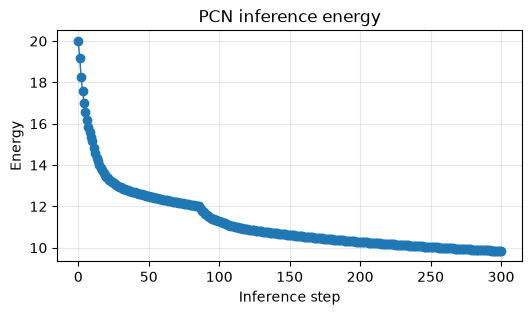

In [9]:
# Fuehre diese Zelle aus, wenn Inferenz implementiert ist.
x_demo = RNG.normal(size=(16, dims[0]))
weights = init_weights(dims)
states_after, e_hist = run_inference(weights, x_demo, dims, T_infer=300, eta_infer=0.03)

plt.figure(figsize=(6, 3))
plt.plot(e_hist, marker="o", linewidth=1)
plt.xlabel("Inference step")
plt.ylabel("Energy")
plt.title("PCN inference energy")
plt.grid(alpha=0.3)
plt.show();

## 5. Lernen: Gewichte lokal aktualisieren

Nach der Inferenz werden die Gewichte angepasst. Die lokale Lernregel aus dem Paper ist:

$$W^{(l)} \leftarrow W^{(l)} + \eta_{learn}\, h^{(l)}x^{(l+1)T}$$

In Batch-Notation verwendest du den Mittelwert ueber den Batch:

$$\Delta W^{(l)} \propto h^{(l)T}X^{(l+1)}$$

**Deine Aufgabe:** Implementiere `learning_step`. Achte darauf, dass `W[l]` dieselbe Shape behaelt.

In [10]:
def learning_step(weights, states, eta_learn):
    """One local generative-weight update after inference."""
    errors, gain_errors, _, _ = compute_errors(weights, states)
    batch_size = states[0].shape[0]
    new_weights = []

    for l, W_l in enumerate(weights):
        dW_l = gain_errors[l].T @ states[l + 1] / batch_size
        new_weights.append(W_l + eta_learn * dW_l)

    return new_weights

## 6. Erstes unsupervised Training

Jetzt kombinierst du Inferenz und Lernen. Das Modell sieht nur Eingaben $x^{(0)}$ und lernt, sie aus latenten Ursachen zu rekonstruieren.

**Deine Aufgabe:**
- Iteriere ueber Mini-Batches.
- Fuehre pro Batch zuerst Inferenz aus.
- Aktualisiere danach die Gewichte.
- Speichere Energieverlaeufe fuer die Diagnose.

In [20]:
def iterate_minibatches(X, batch_size, rng=RNG, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        rng.shuffle(indices)
    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx]

def train_unsupervised_pcn(X, dims, epochs=10, batch_size=32, T_infer=30, eta_infer=0.03, eta_learn=0.001):
    weights = init_weights(dims)
    epoch_energy = []

    for _ in tqdm(range(epochs)):
        batch_energies = []
        for x_batch in iterate_minibatches(X, batch_size):
            states, history = run_inference(weights, x_batch, dims, T_infer=T_infer, eta_infer=eta_infer)
            weights = learning_step(weights, states, eta_learn)
            batch_energies.append(history[-1])

        mean_energy = float(np.mean(batch_energies))
        epoch_energy.append(mean_energy)

    return weights, np.array(epoch_energy)

## 7. Toy-Datensatz vorbereiten

Als erstes Experiment verwenden wir `make_moons`. Das ist klein genug, um Fehler in der PCN-Mechanik schnell zu sehen.

Nutze die Labels erst spaeter fuer die supervised Erweiterung. Fuer das unsupervised PCN wird nur `X_train` verwendet.

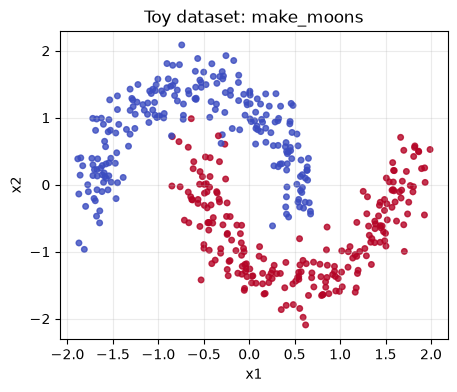

In [21]:
X, y = make_moons(n_samples=600, noise=0.12, random_state=42)
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=16, cmap="coolwarm", alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Toy dataset: make_moons")
plt.grid(alpha=0.25)
plt.show();

### Check 3: Unsupervised Training starten

Wenn deine Funktionen implementiert sind, sollte dieser Block ohne Shape-Fehler laufen. Erwarte keine Klassifikationsleistung; hier lernst du zuerst nur die rekonstruktive PCN-Dynamik.

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:17<00:00, 29.01it/s]


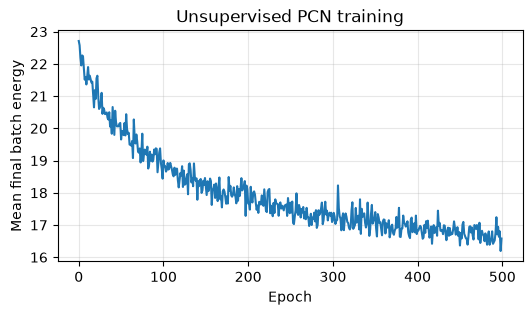

In [49]:
# Fuehre diese Zelle aus, wenn alle unsupervised Bausteine implementiert sind.
pcn_dims = [2, 8, 4]
learned_weights, train_energy = train_unsupervised_pcn(
    X_train, pcn_dims,
    epochs= 500,
    batch_size=32,
    T_infer=50,
    eta_infer=0.05,
    eta_learn=0.005,
)

plt.figure(figsize=(6, 3))
plt.plot(train_energy)
plt.xlabel("Epoch")
plt.ylabel("Mean final batch energy")
plt.title("Unsupervised PCN training")
plt.grid(alpha=0.3)
plt.show();

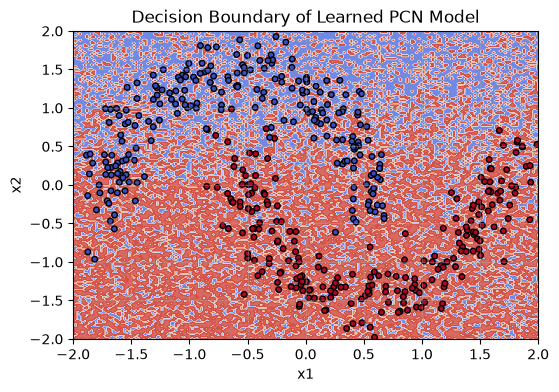

In [51]:
## Visualize the decision boundary of the learned PCN model
def plot_decision_boundary(weights, dims, xlim=(-2, 2), ylim=(-2, 2), resolution=100):
    """Plot the decision boundary of the learned PCN model."""
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], resolution),
                         np.linspace(ylim[0], ylim[1], resolution))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Run inference on the grid points
    states, _ = run_inference(weights, grid_points, dims, T_infer=100, eta_infer=0.03)
    predictions = states[-1]  # Get the top layer activations

    # For binary classification, we can use a threshold on the top layer activation
    predicted_labels = (predictions[:, 0] > predictions[:, 1]).astype(int)

    # Reshape to match the grid shape
    Z = predicted_labels.reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=16, cmap="coolwarm", edgecolor='k')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision Boundary of Learned PCN Model")
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(learned_weights, pcn_dims, xlim=(-2, 2), ylim=(-2, 2), resolution=200) 

## 8. Supervised Erweiterung

Das Einfuehrungspaper erweitert PCNs fuer supervised learning, indem die oberste latente Schicht mit einem Readout verbunden wird. Eine einfache Variante fuer dieses Notebook:

$$\hat{y} = x^{(L)}W_{out}^T$$

$$\epsilon_{sup} = \hat{y} - y$$

Dieser Fehler wirkt auf die oberste latente Schicht zurueck und `W_out` wird nach der Inferenz gelernt.

**Deine Aufgabe:** Baue diese Erweiterung erst, wenn das unsupervised PCN stabil laeuft. Entscheide selbst, ob du MSE auf One-Hot-Targets verwendest oder Softmax/Cross-Entropy spaeter ergaenzt.

In [52]:
def one_hot_labels(y):
    enc = OneHotEncoder(sparse_output=False)
    return enc.fit_transform(y.reshape(-1, 1))

def init_readout(top_dim, output_dim, rng=RNG):
    sigma = np.sqrt(2 / (top_dim + output_dim))
    W_out = sigma * rng.standard_normal((output_dim, top_dim))
    return W_out

def supervised_inference_step(weights, W_out, states, y_batch, eta_infer):
    """Optional: inference update with a supervised top-layer error."""
    errors, gain_errors, _, _ = compute_errors(weights, states)
    new_states = [states[0].copy()]
    L = len(weights)

    # supervised error at the top latent layer
    logits = states[-1] @ W_out.T
    eps_sup = logits - y_batch
    top_error = eps_sup @ W_out  # map output error back to top latent space

    for l in range(1, L + 1):
        eps_l = top_error if l == L else errors[l]
        bottom_up = gain_errors[l - 1] @ weights[l - 1]
        grad = eps_l - bottom_up
        new_states.append(states[l] - eta_infer * grad)
    return new_states


def supervised_learning_step(weights, W_out, states, y_batch, eta_learn):
    """Optional: update generative weights and readout weights."""
    # generative weights
    new_weights = learning_step(weights, states, eta_learn)

    # readout weights
    batch_size = states[0].shape[0]
    logits = states[-1] @ W_out.T
    eps_sup = logits - y_batch
    dW_out = eps_sup.T @ states[-1] / batch_size
    new_W_out = W_out - eta_learn * dW_out

    return new_weights, new_W_out


## 9. Evaluation fuer die supervised Version

Fuer eine faire Evaluation brauchst du eine Funktion, die fuer Testdaten zuerst latente Zustaende inferiert und dann ueber den Readout klassifiziert.

**Deine Aufgabe:**
- Schreibe `predict_supervised_pcn`.
- Berechne Accuracy und F1.
- Zeichne eine Confusion Matrix.
- Vergleiche mit einer simplen Baseline, z.B. logistischer Regression aus scikit-learn.

Accuracy: 0.5066666666666667
F1: 0.5066666666666667


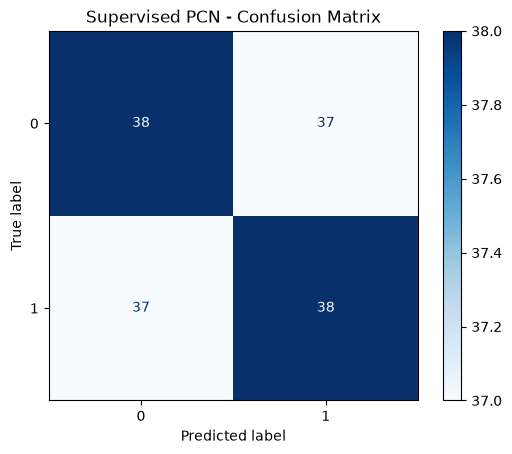

In [54]:
def predict_supervised_pcn(weights, W_out, X, dims, T_infer=30, eta_infer=0.03):
    """Predict class labels using supervised PCN."""
    states, _ = run_inference(weights, X, dims, T_infer, eta_infer)
    logits = states[-1] @ W_out.T  # top latent layer
    return np.argmax(logits, axis=1)

# Initialize W_out for binary classification (2 classes)
output_dim = 2
W_out = init_readout(pcn_dims[-1], output_dim)

# Beispielstruktur fuer spaeter:
y_pred = predict_supervised_pcn(learned_weights, W_out, X_test, pcn_dims)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Supervised PCN - Confusion Matrix")
plt.show();

## 10. Debugging- und Analysefragen

Beantworte diese Fragen im Notebook, sobald deine erste Version laeuft:

1. Sinkt die Energie waehrend der Inferenz fuer einzelne Batches monoton oder nur im Trend?
2. Was passiert, wenn du `eta_infer` verdoppelst?
3. Welche Schicht hat die groessten Prediction Errors?
4. Wie veraendern sich die Normen der latenten Zustaende ueber Inferenzschritte?
5. Wird das Training stabiler, wenn du die Gewichtsskala kleiner waehlst?
6. Was aendert sich, wenn du `tanh` durch eine lineare Aktivierung ersetzt?

Diese Fragen sind nicht Beiwerk: Bei PCNs ist die Dynamik selbst der wichtigste Lerngegenstand.

In [ ]:
def latent_norms(states):
    """Return mean squared norm per state layer. Useful for stability diagnostics."""
    return [float(np.mean(np.sum(x_l ** 2, axis=1))) for x_l in states]

def error_norms(errors):
    """Return mean squared prediction-error norm per generative layer."""
    return [float(np.mean(np.sum(e_l ** 2, axis=1))) for e_l in errors]

# Nutze diese Helper in run_inference, um Norm-Verlaeufe pro Layer zu plotten.


SyntaxError: invalid syntax (1721586683.py, line 8)

## 11. Optionale Erweiterungen

Wenn die Grundversion funktioniert, waehle eine der folgenden Erweiterungen:

- **Bias-Terme:** Ergaenze pro generativer Schicht einen Bias und leite die Updates her.
- **Feed-forward Initialisierung:** Initialisiere Latents nicht zufaellig, sondern aus einem separaten Encoder.
- **Regularisierung:** Fuege eine Norm-Strafe fuer latente Zustaende hinzu und beobachte Stabilitaet.
- **PyTorch-Version:** Uebersetze deine NumPy-Regeln in `torch.no_grad()`-Updates.
- **Mehr Daten:** Teste das Modell auf einem kleinen sklearn-Datensatz wie `digits`.

Achte bei jeder Erweiterung darauf, ob die lokale Struktur der Updates erhalten bleibt.

## Quellen und Theoriehinweise

- Mikko Stenlund, *Introduction to Predictive Coding Networks for Machine Learning*, `ressources/2506.06332v1.pdf`.
- *Towards Stable Learning in Predictive Coding Networks*, `ressources/5667_Towards_Stable_Learning_i.pdf`.

Fuer dieses Notebook sind besonders wichtig: Architektur, Energie, Inferenzupdate, lokales Gewichtsupdate und die Warnung, dass tiefe PCNs durch schlecht kontrollierte latente Normen instabil werden koennen.